In [1]:
from pathlib import Path

import numpy as np
import tifffile

from skimage.exposure import rescale_intensity
from skimage.segmentation import find_boundaries
import skimage.io as io

import matplotlib.pyplot as plt

/Users/m298117/anaconda3/envs/senoquant-dev/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
NPZ_PATH = Path("tissuenet_v1.1_test.npz")
SAVE_PATH = Path("test_npys")
SAVE_PATH.mkdir(exist_ok=True, parents=True)

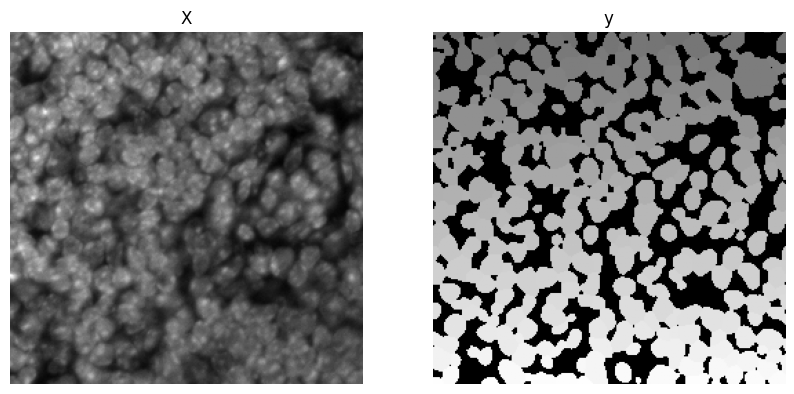

In [3]:
# Convert each array in the NPZ file to a TIFF file
with np.load(NPZ_PATH, allow_pickle=True) as data:
    X = data["X"]
    y = data["y"]

    X_folder = SAVE_PATH / "X"
    y_folder = SAVE_PATH / "y"
    X_folder.mkdir(exist_ok=True)
    y_folder.mkdir(exist_ok=True)

    image = 630

    selected_X = X[image, :, :, :]
    selected_X = np.expand_dims(selected_X, axis=0)
    selected_y = y[image, :, :, :]
    selected_y = np.expand_dims(selected_y, axis=0)

    # Display X and y
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(selected_X[0, :, :, 0], cmap="gray")
    plt.title("X")
    plt.axis("off")
    plt.subplot(1, 2, 2)
    plt.imshow(selected_y[0, :, :, 1], cmap="gray")
    plt.title("y")
    plt.axis("off")
    plt.show()

    for i in range(X.shape[0]):
        np.save(X_folder / f"{i}.npy", X[i, :, :, 0])
        np.save(y_folder / f"{i}.npy", y[i, :, :, 1])